In [41]:
from utils import *
import pandas as pd
import glob, os

In [42]:
def safe_map(func):
    def wrapper(x):
        try:
            return func(x)
        except Exception:
            return None

    return wrapper

In [43]:
dfs = []
for file in glob.glob(f"../results/experiment*scaling*.csv"):
    dfs.append(pd.read_csv(file))
df = pd.concat(dfs, ignore_index=True)
for col in df.columns:
    if col.endswith("times"):
        df[col] = df[col].apply(safe_map(ast.literal_eval))
df["metadata"] = df["metadata"].apply(safe_map(ast.literal_eval))
df["solvers m"] = df["solvers m"].apply(lambda m: "-" if pd.isna(m) else m)
df["coarse m"] = df["coarse m"].apply(lambda m: "-" if pd.isna(m) else m)
df["p"] = df["p"].apply(int)

In [44]:
def nice_solver_name(name):
    if "AMGX" in name:
        return "AmgX"
    if "Hybrid" in name:
        return "Hybrid Schwarz"
    if "Additive" in name:
        return "Additive Schwarz"
    return None

In [45]:
df["best solve time"] = df["solve times"].apply(min)
df["best DoFs/s"] = df.apply(
    lambda row: row["DoFs"] / row["best solve time"],
    axis=1,
)
df["nice solver"] = df["solver"].apply(nice_solver_name)
df["fine m val"] = df["fine m"].apply(lambda m: int(m[1:]))

In [47]:
pivot = df.pivot_table(
    values="best DoFs/s",
    index=["p", "solver"],
    columns=["fine m val"]
)
pivot

fine m val                                                   4           5   \
p solver                                                                      
1 CG(AMGX(L1_TRUNC, torch.float32), bsr_matmul=Fa...        NaN  462.435551   
  CG(AMGX(L1_TRUNC, torch.float32), bsr_matmul=True)        NaN  179.787730   
  CG(AdditiveSchwarz(torch.float32, Inv(torch.flo...        NaN  216.649274   
  CG(AdditiveSchwarz(torch.float32, Inv(torch.flo...        NaN   92.169486   
  CG(HybridSchwarz(torch.float64, Inv(torch.float...        NaN  376.662616   
  CG(HybridSchwarz(torch.float64, Inv(torch.float...        NaN  158.446822   
3 CG(AMGX(L1_TRUNC, torch.float32), bsr_matmul=True)  87.108580  306.576693   
  CG(AdditiveSchwarz(torch.float32, Inv(torch.flo...  38.251925  129.599439   
  CG(HybridSchwarz(torch.float64, Inv(torch.float...  62.207336  240.075676   

fine m val                                                     6   \
p solver                                                            
1 CG(AMGX(L1_TRUNC, torch.float32), bsr_matmul=Fa...  1481.841625   
  CG(AMGX(L1_TRUNC, torch.float32), bsr_matmul=True)   631.538972   
  CG(AdditiveSchwarz(torch.float32, Inv(torch.flo...   707.584290   
  CG(AdditiveSchwarz(torch.float32, Inv(torch.flo...   318.698924   
  CG(HybridSchwarz(torch.float64, Inv(torch.float...  1372.749849   
  CG(HybridSchwarz(torch.float64, Inv(torch.float...   607.188044   
3 CG(AMGX(L1_TRUNC, torch.float32), bsr_matmul=True)   993.558568   
  CG(AdditiveSchwarz(torch.float32, Inv(torch.flo...   494.523163   
  CG(HybridSchwarz(torch.float64, Inv(torch.float...   912.123640   

fine m val                                                     7   \
p solver                                                            
1 CG(AMGX(L1_TRUNC, torch.float32), bsr_matmul=Fa...  4229.488123   
  CG(AMGX(L1_TRUNC, torch.float32), bsr_matmul=True)  2135.645410   
  CG(AdditiveSchwarz(torch.float32, Inv(torch.flo...  2673.733987   
  CG(AdditiveSchwarz(torch.float32, Inv(torch.flo...  1248.036702   
  CG(HybridSchwarz(torch.float64, Inv(torch.float...  4648.762531   
  CG(HybridSchwarz(torch.float64, Inv(torch.float...  2345.439312   
3 CG(AMGX(L1_TRUNC, torch.float32), bsr_matmul=True)  2414.113287   
  CG(AdditiveSchwarz(torch.float32, Inv(torch.flo...  1636.855582   
  CG(HybridSchwarz(torch.float64, Inv(torch.float...  2720.841211   

fine m val                                                      8   \
p solver                                                             
1 CG(AMGX(L1_TRUNC, torch.float32), bsr_matmul=Fa...  10157.268898   
  CG(AMGX(L1_TRUNC, torch.float32), bsr_matmul=True)   6554.669758   
  CG(AdditiveSchwarz(torch.float32, Inv(torch.flo...   7996.324758   
  CG(AdditiveSchwarz(torch.float32, Inv(torch.flo...   4899.494252   
  CG(HybridSchwarz(torch.float64, Inv(torch.float...  10277.590286   
  CG(HybridSchwarz(torch.float64, Inv(torch.float...   9517.539358   
3 CG(AMGX(L1_TRUNC, torch.float32), bsr_matmul=True)   3447.343728   
  CG(AdditiveSchwarz(torch.float32, Inv(torch.flo...   3512.932636   
  CG(HybridSchwarz(torch.float64, Inv(torch.float...   4845.117828   

fine m val                                                      9   \
p solver                                                             
1 CG(AMGX(L1_TRUNC, torch.float32), bsr_matmul=Fa...  12783.318449   
  CG(AMGX(L1_TRUNC, torch.float32), bsr_matmul=True)  11134.397796   
  CG(AdditiveSchwarz(torch.float32, Inv(torch.flo...  11797.908923   
  CG(AdditiveSchwarz(torch.float32, Inv(torch.flo...  12186.260526   
  CG(HybridSchwarz(torch.float64, Inv(torch.float...  14921.404019   
  CG(HybridSchwarz(torch.float64, Inv(torch.float...  15275.669185   
3 CG(AMGX(L1_TRUNC, torch.float32), bsr_matmul=True)   3805.195958   
  CG(AdditiveSchwarz(torch.float32, Inv(torch.flo...   4062.800972   
  CG(HybridSchwarz(torch.float64, Inv(torch.float...   6297.221894   

fine m val                                                      10  

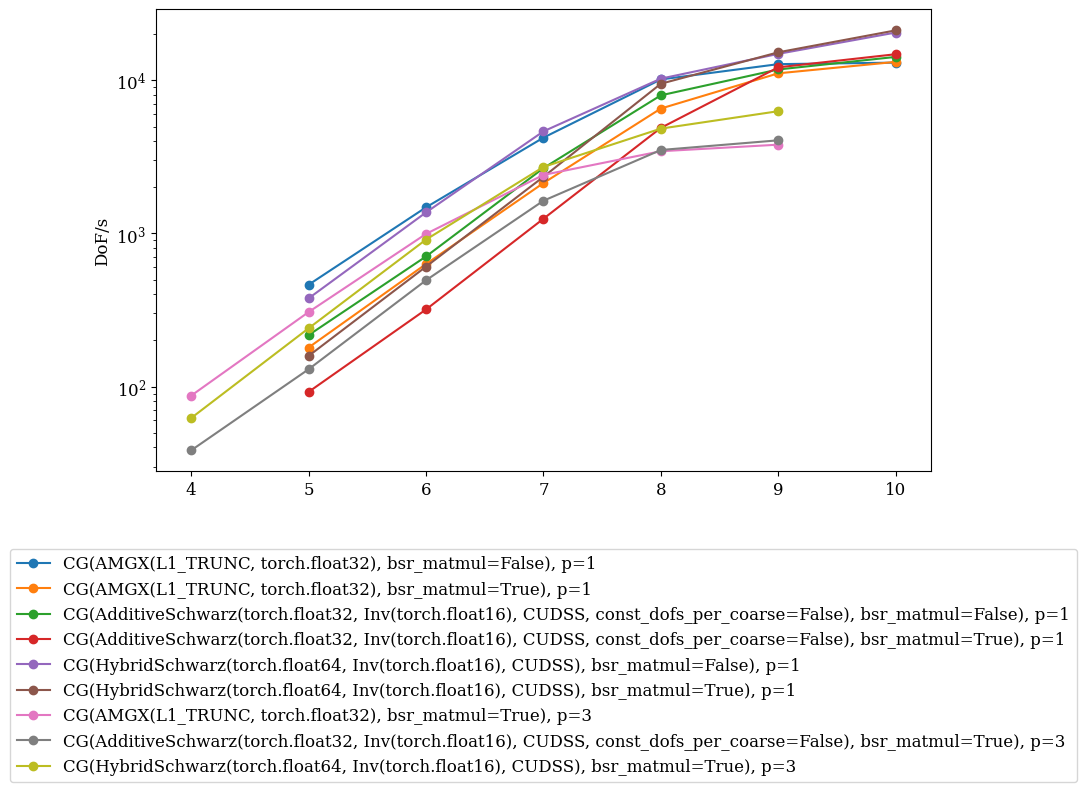

In [54]:
fig, ax = plt.subplots(figsize=(10, 6))
for (p, solver), vals in pivot.iterrows():
    # if p != 1:
    #     continue
    ax.plot(vals, label=f"{solver}, p={p}", marker="o")
ax.set_yscale("log")
ax.set_ylabel("DoF/s")

#legend below the plot
ax.legend(bbox_to_anchor=(0.5, -0.15), loc="upper center", ncol=1)